# Analisi crittoanalitica del crittogramma

Questo notebook documenta l'analisi crittoanalitica del crittogramma fornito come assignment.

L'obiettivo è raccogliere evidenze statistiche e strutturali per orientare l'indagine sul cifrario utilizzato, senza assumere a priori una soluzione. L'analisi considera le principali famiglie di cifrari affrontate nel corso:

- cifrari a trasposizione;
- cifrari a sostituzione monoalfabetica;
- cifrari polialfabetici, con particolare attenzione a Vigenère;
- cifrari a digrammi, con particolare attenzione a Playfair.

L'intero processo è svolto in **Jupyter Notebook**, così da rendere riproducibili caricamento dei dati, calcoli, grafici e conclusioni.

## 1. Caricamento e normalizzazione del crittogramma

Il crittogramma viene letto dal file `crittogramma.txt`.

La normalizzazione mantiene solo le lettere `A-Z`, eliminando spazi, a capo e caratteri non alfabetici. Questa operazione è necessaria per rendere coerenti frequenze, n-grammi, indice di coincidenza e test sulle sequenze ripetute.

In [2]:
from pathlib import Path
import re
import math
from collections import Counter, defaultdict
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt

CRYPTOGRAM_FILE = Path("./crittogramma.txt")
OUTPUT_DIR = Path("./grafici_analisi_crittogramma")
OUTPUT_DIR.mkdir(exist_ok=True)

def normalize_text(text: str) -> str:
    return re.sub(r"[^A-Z]", "", text.upper())

ciphertext_raw = CRYPTOGRAM_FILE.read_text(encoding="utf-8")
ciphertext = normalize_text(ciphertext_raw)

N = len(ciphertext)
alphabet = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
counts = Counter(ciphertext)

print(f"Lunghezza testo normalizzato: {N}")
print(f"Prime 100 lettere: {ciphertext[:100]}")
print(f"Ultime 100 lettere: {ciphertext[-100:]}")
print(f"Lettere presenti: {''.join([c for c in alphabet if counts[c] > 0])}")
print(f"Lettere assenti: {[c for c in alphabet if counts[c] == 0]}")

Lunghezza testo normalizzato: 1448
Prime 100 lettere: VIANPGMIIMQCTLQVPQRCFINUVOLUNTICGZSYNAQYPGFIMNTDNGGBFIMNIOVOHINLMIVYRCLTLHNQBRQCTORCXYCGATIMCRIHSBRQ
Ultime 100 lettere: INPFDNHQYMGSBVYAMCRICQBCKCHLNTDPCSKUNMTNIHDPNPHYHENQCTBLLNYVCLHYLWIFIGNALHMTDIQVPQRCFINUVONTLBYZYLNP
Lettere presenti: ABCDEFGHIKLMNOPQRSTUVWXYZ
Lettere assenti: ['J']


## 2. Osservazione preliminare sull'alfabeto

Una prima evidenza riguarda l'alfabeto effettivamente osservato nel crittogramma.

L'assenza della lettera **J** non è un dettaglio marginale. Nei cifrari classici può indicare:

- uso di un alfabeto ridotto a 25 lettere;
- fusione `I/J`;
- impiego di una matrice 5×5;
- compatibilità con cifrari a digrammi come **Playfair**.

Questo elemento non dimostra da solo l'uso di Playfair, ma costituisce un indizio strutturale importante da verificare con analisi specifiche sui digrammi.

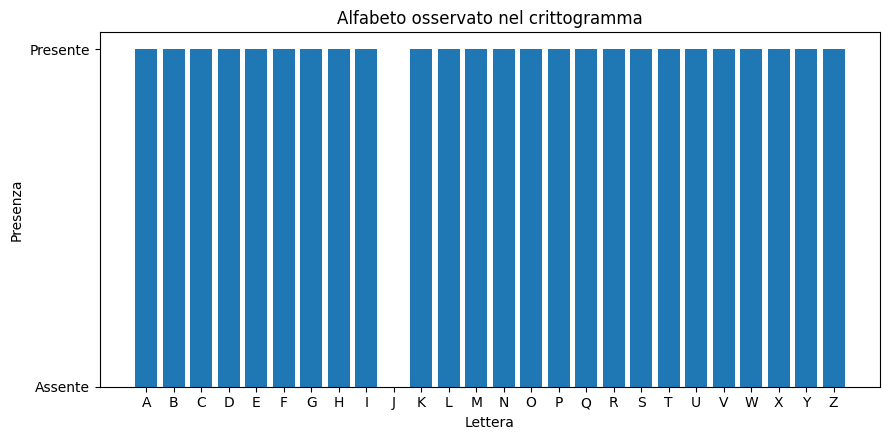

In [3]:
present = [1 if counts[c] > 0 else 0 for c in alphabet]

plt.figure(figsize=(9, 4.5))
plt.bar(alphabet, present)
plt.title("Alfabeto osservato nel crittogramma")
plt.xlabel("Lettera")
plt.ylabel("Presenza")
plt.yticks([0, 1], ["Assente", "Presente"])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_alfabeto_osservato.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Frequenze dei monogrammi

L'analisi delle frequenze delle singole lettere è il primo passo della crittoanalisi statistica.

- In un cifrario a **trasposizione**, le lettere non cambiano: la distribuzione dovrebbe restare simile a quella della lingua naturale.
- In una **sostituzione monoalfabetica**, la forma della distribuzione tende a conservarsi, ma cambiano le etichette delle lettere.
- In un cifrario **polialfabetico** o a **digrammi**, la distribuzione può risultare più appiattita.

In [4]:
freq = {c: counts[c] / N * 100 for c in alphabet}

df_freq = pd.DataFrame({
    "Lettera": alphabet,
    "Conteggio": [counts[c] for c in alphabet],
    "Freq_%": [freq[c] for c in alphabet],
}).sort_values("Freq_%", ascending=False)

df_freq

,Lettera,Conteggio,Freq_%
13,N,133,9.185083
11,L,122,8.425414
8,I,114,7.872928
2,C,96,6.629834
12,M,95,6.560773
24,Y,80,5.524862
7,H,74,5.110497
16,Q,69,4.765193
6,G,66,4.558011
0,A,58,4.005525


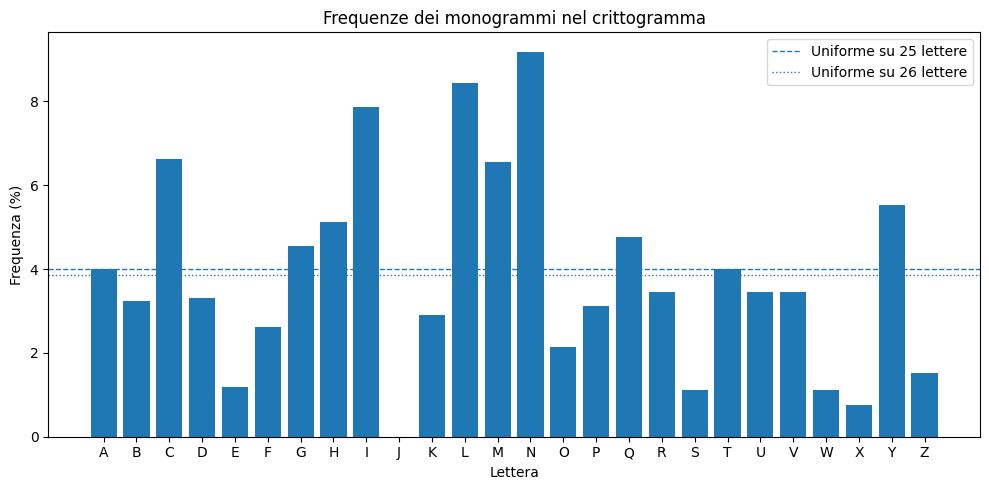

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(alphabet, [freq[c] for c in alphabet])
plt.axhline(100/25, linestyle="--", linewidth=1, label="Uniforme su 25 lettere")
plt.axhline(100/26, linestyle=":", linewidth=1, label="Uniforme su 26 lettere")
plt.title("Frequenze dei monogrammi nel crittogramma")
plt.xlabel("Lettera")
plt.ylabel("Frequenza (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_frequenze_monogrammi.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Confronto con italiano e inglese

Il confronto con le distribuzioni di frequenza dell'italiano e dell'inglese deve essere interpretato con cautela.

Il confronto lettera-per-lettera è più significativo per l'ipotesi di trasposizione, perché la trasposizione conserva le lettere del testo originale. Per la sostituzione monoalfabetica, invece, è più informativo il confronto per **ranking**, cioè la forma della distribuzione ordinata dalla lettera più frequente alla meno frequente.

Per supportare questo confronto vengono usati alcuni **indici di similarità e distanza**. Senza entrare troppo nel dettaglio matematico, possono essere letti così:

- **Differenza assoluta**: misura lo scostamento complessivo tra due profili di frequenza. Valori più bassi indicano maggiore vicinanza.
- **Distanza euclidea**: interpreta le frequenze come coordinate in uno spazio multidimensionale. È utile per stimare quanto due distribuzioni siano distanti in termini geometrici.
- **Correlazione**: misura se due profili "si muovono insieme". Se una lettera è relativamente frequente in un profilo e tende a esserlo anche nell'altro, la correlazione cresce.
- **Cosine similarity**: confronta soprattutto la forma complessiva delle distribuzioni. È utile quando interessa capire se due profili hanno un andamento simile, anche senza pretendere una sovrapposizione perfetta.

Dal punto di vista operativo, questi indici non identificano direttamente il cifrario, ma aiutano a capire se il crittogramma mantiene ancora un'impronta linguistica riconoscibile oppure se tale impronta è stata attenuata dalla cifratura.

In [6]:
it_freq = {
    "A":11.74,"B":0.92,"C":4.50,"D":3.73,"E":11.79,"F":0.95,"G":1.64,"H":1.54,
    "I":11.28,"J":0.00,"K":0.00,"L":6.51,"M":2.51,"N":6.88,"O":9.83,"P":3.05,
    "Q":0.51,"R":6.37,"S":4.98,"T":5.62,"U":3.01,"V":2.10,"W":0.00,"X":0.00,
    "Y":0.00,"Z":0.49
}

en_freq = {
    "A":8.17,"B":1.49,"C":2.78,"D":4.25,"E":12.70,"F":2.23,"G":2.02,"H":6.09,
    "I":6.97,"J":0.15,"K":0.77,"L":4.03,"M":2.41,"N":6.75,"O":7.51,"P":1.93,
    "Q":0.10,"R":5.99,"S":6.33,"T":9.06,"U":2.76,"V":0.98,"W":2.36,"X":0.15,
    "Y":1.97,"Z":0.07
}

def l1_distance(a, b):
    return sum(abs(a[x] - b[x]) for x in alphabet)

def euclidean_distance(a, b):
    return math.sqrt(sum((a[x] - b[x])**2 for x in alphabet))

def cosine_similarity(a, b):
    num = sum(a[x] * b[x] for x in alphabet)
    da = math.sqrt(sum(a[x]**2 for x in alphabet))
    db = math.sqrt(sum(b[x]**2 for x in alphabet))
    return num / (da * db)

def pearson_corr(a, b):
    av = [a[x] for x in alphabet]
    bv = [b[x] for x in alphabet]
    ma = sum(av) / len(av)
    mb = sum(bv) / len(bv)
    num = sum((x-ma)*(y-mb) for x, y in zip(av, bv))
    da = math.sqrt(sum((x-ma)**2 for x in av))
    db = math.sqrt(sum((y-mb)**2 for y in bv))
    return num / (da * db)

df_metrics = pd.DataFrame([
    {
        "Lingua": "Italiano",
        "Diff_assoluta": l1_distance(freq, it_freq),
        "Dist_euclidea": euclidean_distance(freq, it_freq),
        "Correlazione": pearson_corr(freq, it_freq),
        "Cosine_similarity": cosine_similarity(freq, it_freq),
    },
    {
        "Lingua": "Inglese",
        "Diff_assoluta": l1_distance(freq, en_freq),
        "Dist_euclidea": euclidean_distance(freq, en_freq),
        "Correlazione": pearson_corr(freq, en_freq),
        "Cosine_similarity": cosine_similarity(freq, en_freq),
    }
])

df_metrics

,Lingua,Diff_assoluta,Dist_euclidea,Correlazione,Cosine_similarity
0,Italiano,76.586354,19.770940,0.275081,0.707676
1,Inglese,74.371271,18.945316,0.143689,0.701107


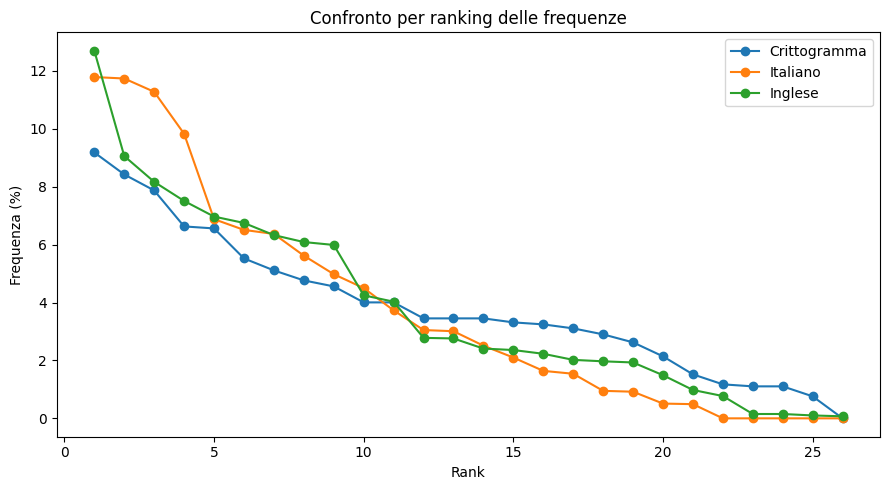

In [7]:
plt.figure(figsize=(9, 5))
for label, f in [("Crittogramma", freq), ("Italiano", it_freq), ("Inglese", en_freq)]:
    values = sorted(f.values(), reverse=True)
    plt.plot(range(1, 27), values, marker="o", label=label)

plt.title("Confronto per ranking delle frequenze")
plt.xlabel("Rank")
plt.ylabel("Frequenza (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_confronto_ranking_frequenze.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Entropia e Indice di Coincidenza

L'**Indice di Coincidenza (IC)** e l'**entropia** sono due indicatori utili per descrivere il comportamento statistico del testo cifrato.

### Indice di Coincidenza

L'IC misura, in modo intuitivo, quanto spesso due lettere scelte nel testo tendono a coincidere. Per un informatico può essere letto come un indicatore di **ridondanza** o di **concentrazione** della distribuzione:

- se tutte le lettere compaiono con frequenza simile, l'IC è basso;
- se alcune lettere compaiono molto più spesso di altre, l'IC aumenta;
- un testo naturale tende ad avere IC più alto di una sequenza casuale, perché le lingue hanno frequenze caratteristiche.

Per questo motivo, l'IC è utile per distinguere tra testi molto appiattiti statisticamente e testi che conservano ancora una struttura linguistica.

### Entropia

L'entropia misura quanta **varietà** o **imprevedibilità** c'è nella distribuzione dei simboli:

- entropia alta significa distribuzione più uniforme e quindi meno prevedibile;
- entropia bassa significa che alcune lettere dominano maggiormente, quindi il testo presenta una struttura più marcata.

In questa analisi IC ed entropia vengono letti insieme: l'IC evidenzia quanto il testo si discosta dalla casualità in termini di ripetizione dei simboli, mentre l'entropia indica quanto il profilo delle frequenze è concentrato o distribuito.

Valori di riferimento:

- testo uniforme su 26 lettere: circa `1/26 = 0,0385`;
- testo uniforme su 25 lettere: circa `1/25 = 0,0400`;
- italiano/inglese naturale: valori sensibilmente più alti, tipicamente nell'ordine di `0,066–0,074`.

Un IC intermedio indica che il testo non è casuale, ma che le frequenze sono più appiattite rispetto a una lingua naturale.

In [8]:
def index_of_coincidence(text: str) -> float:
    n = len(text)
    if n <= 1:
        return float("nan")
    c = Counter(text)
    return sum(v * (v - 1) for v in c.values()) / (n * (n - 1))

def entropy_from_counts(c: Counter) -> float:
    total = sum(c.values())
    h = 0.0
    for value in c.values():
        if value:
            p = value / total
            h -= p * math.log2(p)
    return h

ic_global = index_of_coincidence(ciphertext)
entropy_global = entropy_from_counts(counts)

df_ic = pd.DataFrame([
    {"Indicatore": "IC osservato", "Valore": ic_global},
    {"Indicatore": "IC casuale uniforme 25 lettere", "Valore": 1/25},
    {"Indicatore": "IC casuale uniforme 26 lettere", "Valore": 1/26},
    {"Indicatore": "IC inglese tipico", "Valore": 0.0667},
    {"Indicatore": "IC italiano indicativo", "Valore": 0.0738},
    {"Indicatore": "Entropia osservata", "Valore": entropy_global},
    {"Indicatore": "Entropia uniforme 25 lettere", "Valore": math.log2(25)},
    {"Indicatore": "Entropia uniforme 26 lettere", "Valore": math.log2(26)},
])

df_ic

,Indicatore,Valore
0,IC osservato,0.052354
1,IC casuale uniforme 25 lettere,0.040000
2,IC casuale uniforme 26 lettere,0.038462
3,IC inglese tipico,0.066700
4,IC italiano indicativo,0.073800
5,Entropia osservata,4.408461
6,Entropia uniforme 25 lettere,4.643856
7,Entropia uniforme 26 lettere,4.700440


## 6. Analisi dei digrammi e trigrammi

I digrammi e trigrammi permettono di osservare pattern ripetuti e vincoli strutturali non visibili nei soli monogrammi.

Questa analisi è particolarmente importante nel caso di Playfair, perché l'unità di cifratura è il digramma.

In [9]:
def ngram_counts(text: str, n: int) -> Counter:
    return Counter(text[i:i+n] for i in range(len(text)-n+1))

top_digrams = ngram_counts(ciphertext, 2).most_common(30)
top_trigrams = ngram_counts(ciphertext, 3).most_common(30)

df_digrams = pd.DataFrame(top_digrams, columns=["Digramma", "Conteggio"])
df_trigrams = pd.DataFrame(top_trigrams, columns=["Trigramma", "Conteggio"])

display(df_digrams)
display(df_trigrams)

,Digramma,Conteggio
0,FI,20
1,NT,19
2,RC,18
3,LH,18
4,NP,16
5,IM,15
6,NM,15
7,LB,15
8,AN,14
9,IN,13


,Trigramma,Conteggio
0,FIN,7
1,GVD,7
2,QZM,6
3,QVP,5
4,QRC,5
5,INU,5
6,VOL,5
7,IMN,5
8,LWI,5
9,LNY,5


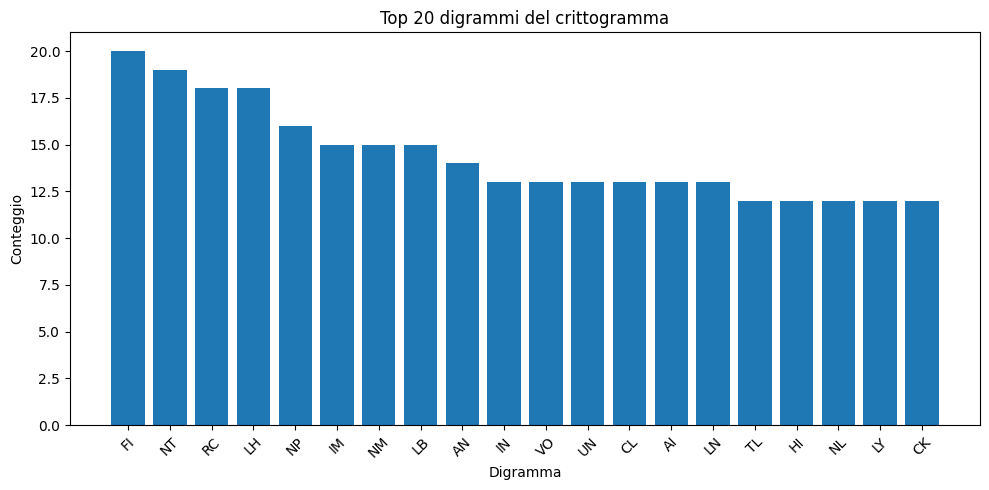

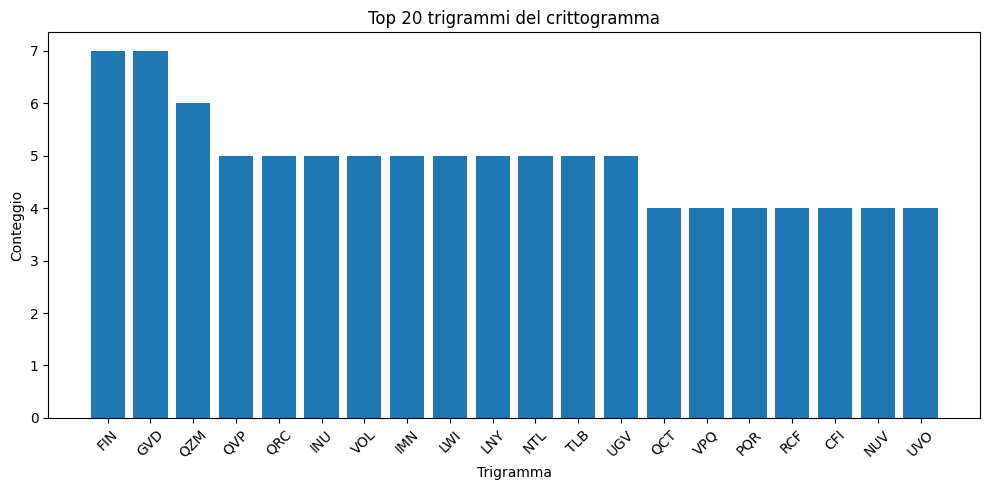

In [10]:
plt.figure(figsize=(10, 5))
items = top_digrams[:20]
plt.bar([x for x, _ in items], [v for _, v in items])
plt.title("Top 20 digrammi del crittogramma")
plt.xlabel("Digramma")
plt.ylabel("Conteggio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_top20_digrammi.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
items = top_trigrams[:20]
plt.bar([x for x, _ in items], [v for _, v in items])
plt.title("Top 20 trigrammi del crittogramma")
plt.xlabel("Trigramma")
plt.ylabel("Conteggio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_top20_trigrammi.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Test Playfair: digrammi doppi sliding e allineati

Per valutare l'ipotesi Playfair è necessario distinguere tra:

- digrammi **sliding**: coppie consecutive `0-1`, `1-2`, `2-3`, ...
- digrammi **allineati**: coppie effettive di cifratura `0-1`, `2-3`, `4-5`, ...

Nel Playfair standard, il testo viene cifrato a coppie. Di conseguenza, un digramma cifrato allineato composto da due lettere uguali dovrebbe essere anomalo. La presenza di un doppio in modalità sliding, invece, non è sufficiente per escludere Playfair, perché quella doppia potrebbe trovarsi a cavallo tra due digrammi effettivi.

La tabella seguente confronta quindi tre viste:

- i doppi trovati con finestra mobile;
- i doppi allineati assumendo offset 0;
- i doppi allineati assumendo offset 1.

Questa distinzione è importante perché, in ottica Playfair, non conta soltanto **quanti** doppi esistono, ma anche **dove** compaiono rispetto alla segmentazione a coppie del crittogramma.

In [11]:
def aligned_digrams(text: str, offset: int = 0) -> list[str]:
    return [text[i:i+2] for i in range(offset, len(text)-1, 2)]

def double_digrams_from_list(digrams: list[str]) -> Counter:
    return Counter(dg for dg in digrams if len(dg) == 2 and dg[0] == dg[1])

sliding_digrams = [ciphertext[i:i+2] for i in range(len(ciphertext)-1)]
doubles_sliding = double_digrams_from_list(sliding_digrams)
doubles_aligned_0 = double_digrams_from_list(aligned_digrams(ciphertext, 0))
doubles_aligned_1 = double_digrams_from_list(aligned_digrams(ciphertext, 1))

all_double_keys = sorted(set(doubles_sliding) | set(doubles_aligned_0) | set(doubles_aligned_1))
df_doubles = pd.DataFrame({
    "Digramma": all_double_keys,
    "Sliding": [doubles_sliding[k] for k in all_double_keys],
    "Allineati_offset_0": [doubles_aligned_0[k] for k in all_double_keys],
    "Allineati_offset_1": [doubles_aligned_1[k] for k in all_double_keys],
}).sort_values("Sliding", ascending=False)

df_doubles

,Digramma,Sliding,Allineati_offset_0,Allineati_offset_1
6,LL,9,8,1
0,AA,4,4,0
3,GG,3,2,1
2,CC,3,3,0
9,QQ,3,3,0
7,NN,2,2,0
5,II,2,1,1
4,HH,2,2,0
1,BB,1,1,0
8,PP,1,1,0


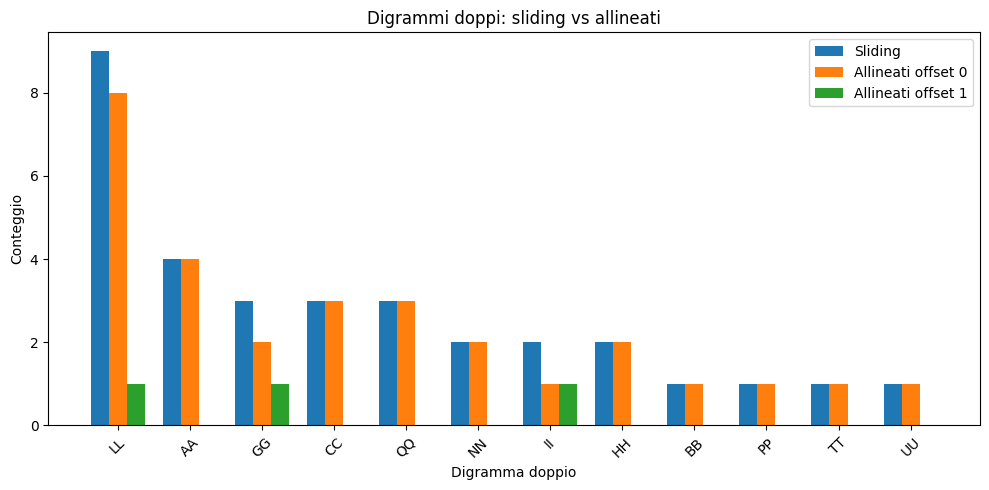

In [12]:
x = range(len(df_doubles))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar([i - width for i in x], df_doubles["Sliding"], width=width, label="Sliding")
plt.bar(list(x), df_doubles["Allineati_offset_0"], width=width, label="Allineati offset 0")
plt.bar([i + width for i in x], df_doubles["Allineati_offset_1"], width=width, label="Allineati offset 1")
plt.xticks(list(x), df_doubles["Digramma"], rotation=45)
plt.title("Digrammi doppi: sliding vs allineati")
plt.xlabel("Digramma doppio")
plt.ylabel("Conteggio")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_digrammi_doppi_sliding_vs_allineati.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Disposizione dei digrammi doppi nel crittogramma

Per l'ipotesi Playfair, una semplice heatmap delle coppie allineate può essere utile, ma non è sempre la rappresentazione più chiara. In questa analisi è più informativo osservare la **disposizione dei digrammi doppi lungo il crittogramma**.

L'obiettivo è passare da una lettura puramente aggregata a una lettura spaziale:

- la timeline dei doppi **allineati** mostra dove compaiono le anomalie rispetto alla segmentazione principale;
- la timeline dei doppi **non allineati** evidenzia i casi presenti nell'offset alternativo, utili come possibili indizi di segmentazione o come candidati separatori;
- la heatmap per blocchi da 100 caratteri mostra se le anomalie sono isolate oppure concentrate in specifiche zone del testo.

Questa rappresentazione è più utile nel contesto Playfair perché permette di valutare non solo la presenza dei doppi, ma anche il loro posizionamento nel crittogramma.

Numero doppi allineati offset 0: 29
Numero doppi non allineati / offset 1: 3
Primi doppi allineati offset 0: [(216, 'LL'), (268, 'LL'), (346, 'LL'), (376, 'NN'), (384, 'NN'), (390, 'HH'), (416, 'AA'), (456, 'AA'), (492, 'QQ'), (506, 'LL')]
Primi doppi non allineati / offset 1: [(7, 'II'), (49, 'GG'), (1403, 'LL')]


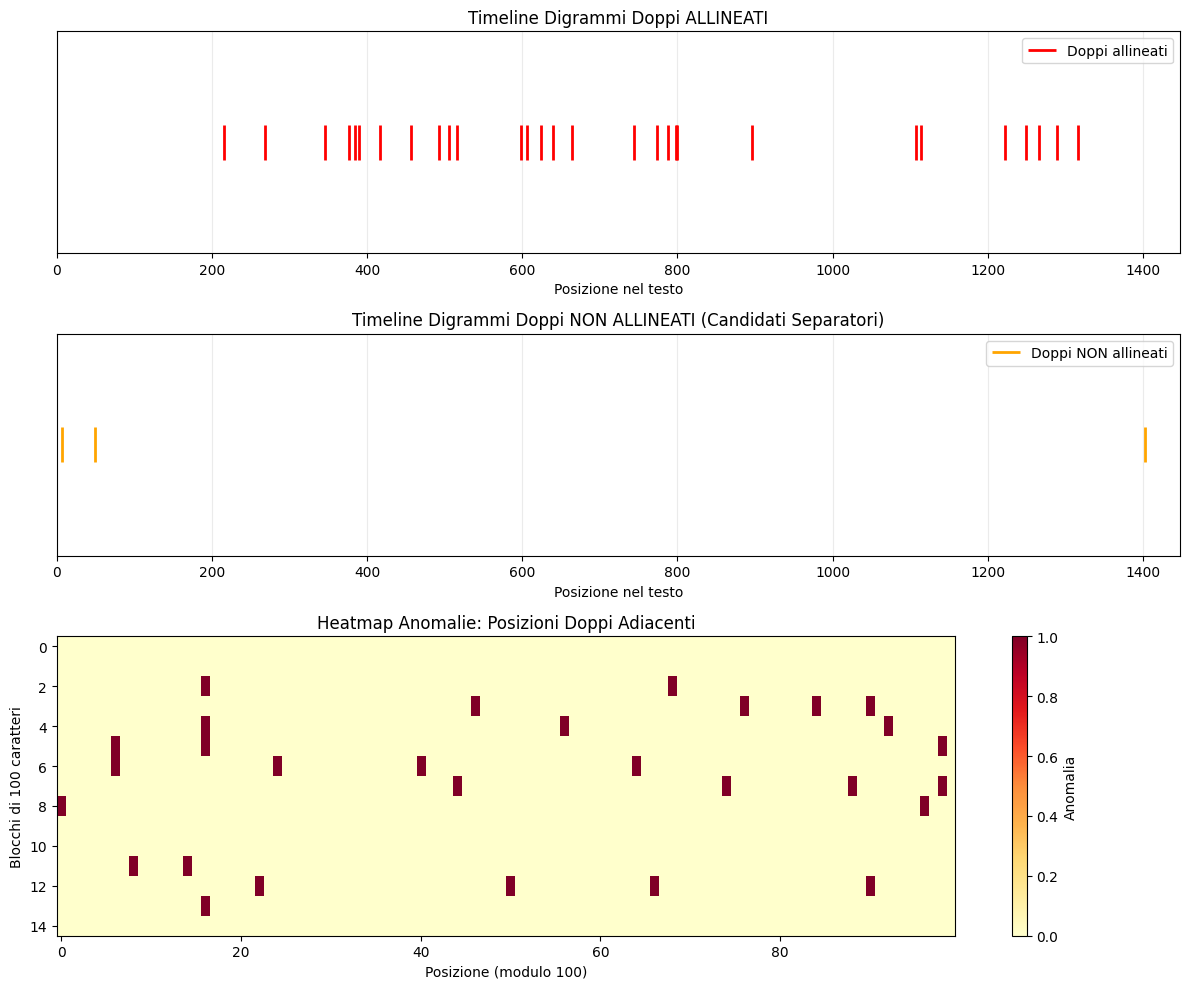

In [13]:
def double_positions_aligned(text: str, offset: int = 0):
    positions = []
    pairs = []
    for i in range(offset, len(text) - 1, 2):
        dg = text[i:i+2]
        if len(dg) == 2 and dg[0] == dg[1]:
            positions.append(i)
            pairs.append(dg)
    return positions, pairs

aligned_positions_0, aligned_pairs_0 = double_positions_aligned(ciphertext, offset=0)
aligned_positions_1, aligned_pairs_1 = double_positions_aligned(ciphertext, offset=1)

print("Numero doppi allineati offset 0:", len(aligned_positions_0))
print("Numero doppi non allineati / offset 1:", len(aligned_positions_1))
print("Primi doppi allineati offset 0:", list(zip(aligned_positions_0[:10], aligned_pairs_0[:10])))
print("Primi doppi non allineati / offset 1:", list(zip(aligned_positions_1[:10], aligned_pairs_1[:10])))

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 10),
    gridspec_kw={"height_ratios": [1, 1, 1.35]}
)

# Timeline digrammi doppi allineati
ax = axes[0]
if aligned_positions_0:
    ax.vlines(aligned_positions_0, 0.42, 0.58, color="red", linewidth=2, label="Doppi allineati")
ax.set_xlim(0, len(ciphertext))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title("Timeline Digrammi Doppi ALLINEATI")
ax.set_xlabel("Posizione nel testo")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper right")

# Timeline digrammi doppi non allineati
ax = axes[1]
if aligned_positions_1:
    ax.vlines(aligned_positions_1, 0.42, 0.58, color="orange", linewidth=2, label="Doppi NON allineati")
ax.set_xlim(0, len(ciphertext))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title("Timeline Digrammi Doppi NON ALLINEATI (Candidati Separatori)")
ax.set_xlabel("Posizione nel testo")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper right")

# Heatmap delle anomalie per blocchi da 100 caratteri
block_size = 100
num_blocks = math.ceil(len(ciphertext) / block_size)
heat = [[0 for _ in range(block_size)] for _ in range(num_blocks)]

for pos in aligned_positions_0:
    block = pos // block_size
    offset = pos % block_size
    heat[block][offset] = 1

ax = axes[2]
im = ax.imshow(heat, aspect="auto", interpolation="nearest", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_title("Heatmap Anomalie: Posizioni Doppi Adiacenti")
ax.set_xlabel("Posizione (modulo 100)")
ax.set_ylabel("Blocchi di 100 caratteri")
fig.colorbar(im, ax=ax, label="Anomalia")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_disposizione_digrammi_doppi.png", dpi=180, bbox_inches="tight")
plt.show()

### Lettura del diagramma di disposizione

Il diagramma mostra che i digrammi doppi allineati non sono soltanto un fenomeno numerico, ma hanno una specifica distribuzione lungo il crittogramma.

La timeline superiore evidenzia i doppi compatibili con l'allineamento principale. La timeline intermedia evidenzia invece i doppi rilevati nell'offset alternativo. La heatmap inferiore organizza le stesse anomalie in blocchi da 100 caratteri, rendendo più semplice individuare eventuali concentrazioni locali.

In ottica Playfair, questa analisi è importante perché il cifrario lavora su coppie di lettere. Se il testo fosse un Playfair standard perfettamente formato, ci si aspetterebbe una presenza molto ridotta, se non nulla, di digrammi doppi cifrati allineati. La loro presenza non esclude automaticamente Playfair, ma suggerisce cautela: possono essere in gioco una variante, una segmentazione diversa, caratteri di riempimento, errori di trascrizione o una trasformazione aggiuntiva.

## 9. Test di Kasiski

Il test di Kasiski cerca sequenze ripetute e analizza le distanze tra le loro occorrenze.

Nel caso di Vigenère, ripetizioni del testo in chiaro cifrate con la stessa porzione di chiave possono produrre sequenze ripetute nel crittogramma. Le distanze tra tali sequenze tendono quindi a essere multipli della lunghezza della chiave.

Dal punto di vista pratico, il test risponde alla domanda: **le ripetizioni presenti nel testo suggeriscono una periodicità?**  
Se sì, quella periodicità può essere un indizio di cifratura polialfabetica.

Il risultato va comunque interpretato con cautela, perché sequenze sovrapposte o ripetizioni derivate dalla stessa porzione lunga possono sovrastimare alcuni fattori, soprattutto quelli piccoli come 2 o 4.

In [14]:
def repeated_sequences_positions(text: str, min_len=3, max_len=6):
    result = {}
    for n in range(min_len, max_len + 1):
        positions_by_seq = defaultdict(list)
        for i in range(len(text) - n + 1):
            positions_by_seq[text[i:i+n]].append(i)
        for seq, positions in positions_by_seq.items():
            if len(positions) > 1:
                result[seq] = positions
    return result

def kasiski_analysis(text: str, min_len=3, max_len=6, max_factor=30):
    reps = repeated_sequences_positions(text, min_len, max_len)
    distances = []

    for seq, positions in reps.items():
        for a, b in combinations(positions, 2):
            distances.append(b - a)

    factor_counts = Counter()
    for d in distances:
        for f in range(2, max_factor + 1):
            if d % f == 0:
                factor_counts[f] += 1

    return reps, Counter(distances), factor_counts

reps, distance_counts, factor_counts = kasiski_analysis(ciphertext)

df_reps = pd.DataFrame(
    [
        {"Sequenza": seq, "Occorrenze": len(pos), "Prime_posizioni": pos[:8]}
        for seq, pos in reps.items()
    ]
).sort_values(["Occorrenze", "Sequenza"], ascending=[False, True])

df_factors = pd.DataFrame(factor_counts.most_common(20), columns=["Fattore", "Occorrenze"])
df_distances = pd.DataFrame(distance_counts.most_common(20), columns=["Distanza", "Frequenza"])

display(df_reps.head(20))
display(df_factors)
display(df_distances)

,Sequenza,Occorrenze,Prime_posizioni
12,FIN,7,"[20, 321, 693, 759, 949, 1347, 1432]"
160,GVD,7,"[408, 488, 646, 782, 886, 902, 1018]"
113,QZM,6,"[227, 405, 779, 1047, 1257, 1301]"
302,FINU,5,"[20, 693, 759, 949, 1432]"
24,IMN,5,"[43, 53, 974, 1136, 1208]"
13,INU,5,"[21, 694, 760, 950, 1433]"
75,LNY,5,"[144, 287, 307, 665, 1404]"
60,LWI,5,"[112, 571, 673, 1206, 1412]"
97,NTL,5,"[185, 699, 843, 955, 1438]"
343,NTLB,5,"[185, 699, 843, 955, 1438]"


,Fattore,Occorrenze
0,2,817
1,4,438
2,3,378
3,5,265
4,8,259
5,7,225
6,10,218
7,6,204
8,16,165
9,21,155


,Distanza,Frequenza
0,739,189
1,256,128
2,483,90
3,110,74
4,389,50
5,673,37
6,190,37
7,1046,34
8,929,34
9,1412,34


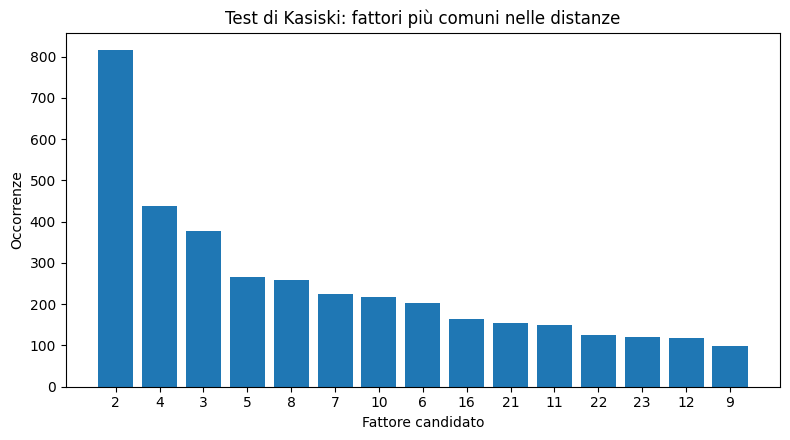

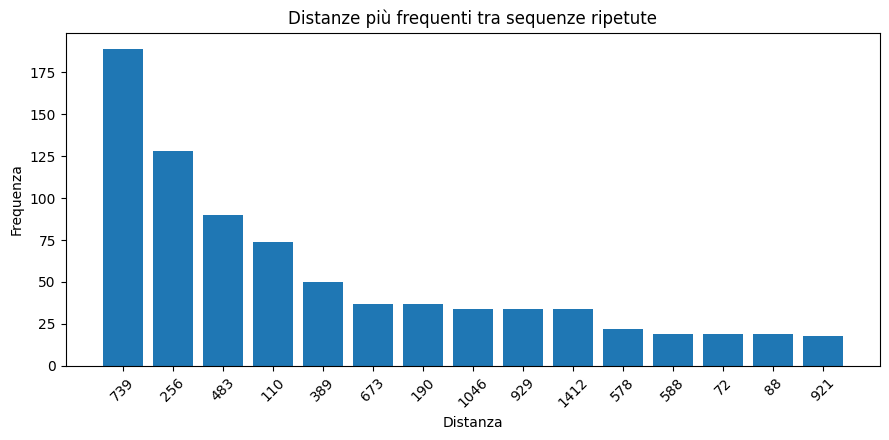

In [15]:
plt.figure(figsize=(8, 4.5))
items = factor_counts.most_common(15)
plt.bar([str(k) for k, _ in items], [v for _, v in items])
plt.title("Test di Kasiski: fattori più comuni nelle distanze")
plt.xlabel("Fattore candidato")
plt.ylabel("Occorrenze")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_kasiski_fattori.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4.5))
items = distance_counts.most_common(15)
plt.bar([str(k) for k, _ in items], [v for _, v in items])
plt.title("Distanze più frequenti tra sequenze ripetute")
plt.xlabel("Distanza")
plt.ylabel("Frequenza")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_kasiski_distanze.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Indice di Coincidenza per sottosequenze

Per verificare l'ipotesi Vigenère si calcola l'IC medio delle colonne ottenute assumendo una lunghezza di chiave `k`.

Se `k` fosse corretto, ogni colonna dovrebbe essere cifrata con lo stesso alfabeto di sostituzione e quindi mostrare un IC più vicino a quello di una lingua naturale.

È importante osservare non solo la media, ma anche la dispersione tra colonne.

### Come leggere questi indici

- **IC medio**: dà una stima della "naturalità media" delle colonne ottenute per un certo `k`.
- **IC minimo / massimo**: mostrano quanto le singole colonne si discostano tra loro.
- **IC_std**: è la deviazione standard; in termini informatici, misura la **stabilità** del risultato. Se è bassa, le colonne si comportano in modo più uniforme; se è alta, il candidato `k` è più instabile.

In pratica, un buon candidato di chiave non dovrebbe avere soltanto un IC medio alto, ma anche un comportamento relativamente coerente tra le colonne. Se i picchi sono piccoli o accompagnati da forte variabilità, il dato va considerato un indizio debole.

In [16]:
def ic_columns_for_k(text: str, k: int):
    cols = [text[i::k] for i in range(k)]
    values = [index_of_coincidence(col) for col in cols if len(col) > 1]
    return values

rows = []
for k in range(1, 41):
    values = ic_columns_for_k(ciphertext, k)
    rows.append({
        "k": k,
        "IC_medio": sum(values) / len(values),
        "IC_min": min(values),
        "IC_max": max(values),
        "IC_std": pd.Series(values).std(),
    })

df_ic_k = pd.DataFrame(rows)
df_ic_k.sort_values("IC_medio", ascending=False).head(15)

,k,IC_medio,IC_min,IC_max,IC_std
35,36,0.054537,0.035897,0.080769,0.010871
25,26,0.054348,0.043506,0.082468,0.008719
29,30,0.054065,0.041667,0.125887,0.015488
17,18,0.053836,0.047222,0.066456,0.006829
12,13,0.053603,0.045206,0.066924,0.005780
9,10,0.053548,0.046743,0.065421,0.005116
38,39,0.053462,0.037538,0.083926,0.011395
31,32,0.053288,0.036364,0.077778,0.011261
28,29,0.053139,0.039184,0.067755,0.007920
19,20,0.053056,0.041080,0.071918,0.008002


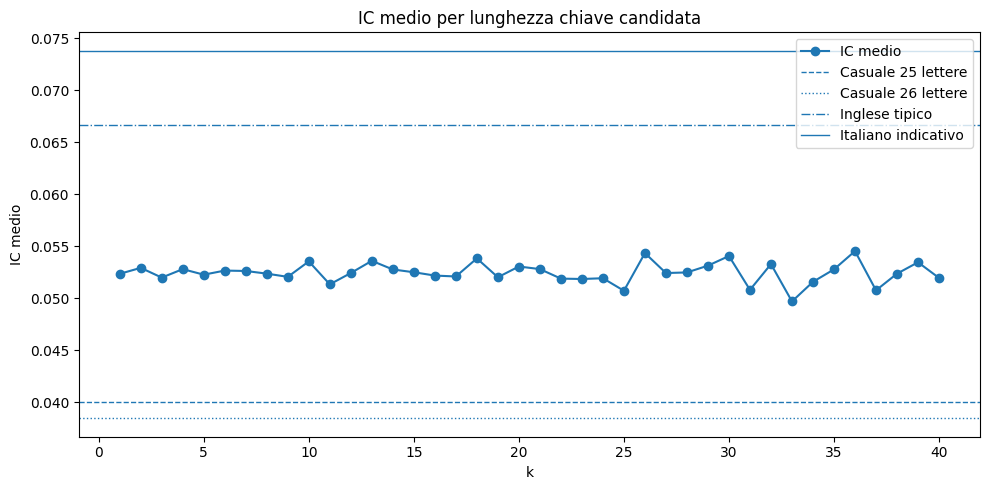

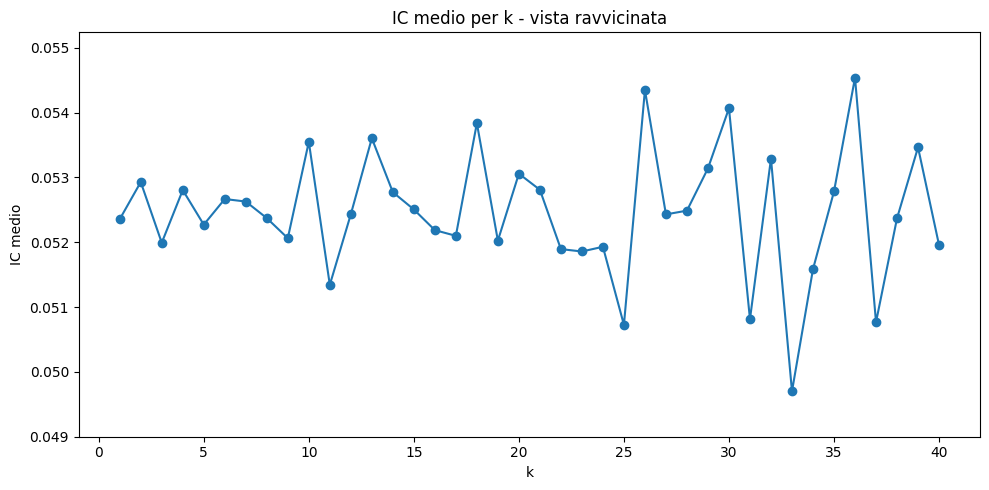

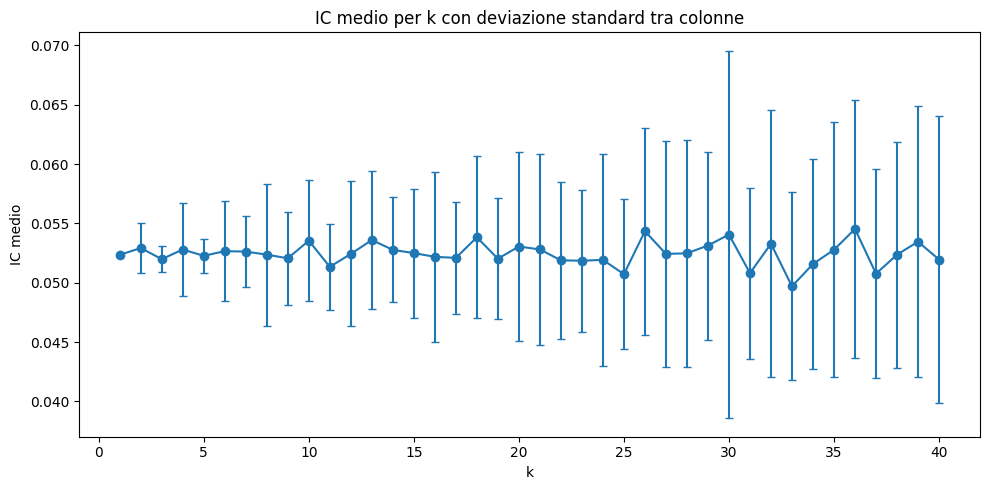

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df_ic_k["k"], df_ic_k["IC_medio"], marker="o", label="IC medio")
plt.axhline(1/25, linestyle="--", linewidth=1, label="Casuale 25 lettere")
plt.axhline(1/26, linestyle=":", linewidth=1, label="Casuale 26 lettere")
plt.axhline(0.0667, linestyle="-.", linewidth=1, label="Inglese tipico")
plt.axhline(0.0738, linestyle="-", linewidth=1, label="Italiano indicativo")
plt.title("IC medio per lunghezza chiave candidata")
plt.xlabel("k")
plt.ylabel("IC medio")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_ic_medio_per_k.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_ic_k["k"], df_ic_k["IC_medio"], marker="o")
plt.title("IC medio per k - vista ravvicinata")
plt.xlabel("k")
plt.ylabel("IC medio")
plt.ylim(df_ic_k["IC_medio"].min() - 0.0007, df_ic_k["IC_medio"].max() + 0.0007)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_ic_medio_per_k_zoom.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.errorbar(df_ic_k["k"], df_ic_k["IC_medio"], yerr=df_ic_k["IC_std"], marker="o", capsize=3)
plt.title("IC medio per k con deviazione standard tra colonne")
plt.xlabel("k")
plt.ylabel("IC medio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_ic_medio_per_k_con_std.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Lettura delle ipotesi

### Trasposizione semplice

Una trasposizione conserva le frequenze del testo originale. Se la distribuzione del crittogramma è sensibilmente più piatta rispetto a italiano/inglese, l'ipotesi di pura trasposizione si indebolisce.

### Sostituzione monoalfabetica

Una sostituzione monoalfabetica conserva la forma della distribuzione, ma cambia le etichette. Il confronto per ranking permette di valutare se la forma osservata è compatibile con una lingua naturale.

### Vigenère / polialfabetico

Un IC intermedio può essere compatibile con un cifrario polialfabetico. Tuttavia la lunghezza della chiave deve emergere da una convergenza tra Kasiski e IC per sottosequenze. Se i due test non convergono o i picchi sono poco marcati, l'ipotesi resta possibile ma non conclusiva.

### Playfair / cifrario a digrammi

L'assenza della **J** e l'uso apparente di un alfabeto a 25 lettere sono elementi compatibili con Playfair. La verifica più importante è l'analisi dei digrammi allineati e dei digrammi doppi allineati.

In [18]:
top_letters = df_freq.head(5)[["Lettera", "Freq_%"]].to_dict("records")
missing_letters = [c for c in alphabet if counts[c] == 0]

top_kasiski = df_factors.head(5).to_dict("records")
top_ic_k = df_ic_k.sort_values("IC_medio", ascending=False).head(5)[["k", "IC_medio", "IC_std"]].to_dict("records")

summary = {
    "lunghezza": N,
    "lettere_assenti": missing_letters,
    "top_5_lettere": top_letters,
    "ic_globale": ic_global,
    "entropia": entropy_global,
    "top_5_fattori_kasiski": top_kasiski,
    "top_5_k_per_ic": top_ic_k,
    "digrammi_doppi_allineati_offset_0": int(df_doubles["Allineati_offset_0"].sum()),
    "digrammi_doppi_allineati_offset_1": int(df_doubles["Allineati_offset_1"].sum()),
}

summary

{'lunghezza': 1448,
 'lettere_assenti': ['J'],
 'top_5_lettere': [{'Lettera': 'N', 'Freq_%': 9.185082872928177},
  {'Lettera': 'L', 'Freq_%': 8.425414364640885},
  {'Lettera': 'I', 'Freq_%': 7.872928176795579},
  {'Lettera': 'C', 'Freq_%': 6.629834254143646},
  {'Lettera': 'M', 'Freq_%': 6.560773480662983}],
 'ic_globale': 0.0523544616982364,
 'entropia': 4.4084612713872,
 'top_5_fattori_kasiski': [{'Fattore': 2, 'Occorrenze': 817},
  {'Fattore': 4, 'Occorrenze': 438},
  {'Fattore': 3, 'Occorrenze': 378},
  {'Fattore': 5, 'Occorrenze': 265},
  {'Fattore': 8, 'Occorrenze': 259}],
 'top_5_k_per_ic': [{'k': 36,
   'IC_medio': 0.05453668959766521,
   'IC_std': 0.010871289109444265},
  {'k': 26, 'IC_medio': 0.05434750434750435, 'IC_std': 0.008719081556522472},
  {'k': 30, 'IC_medio': 0.054065349544072945, 'IC_std': 0.01548806922751671},
  {'k': 18, 'IC_medio': 0.053835668767689394, 'IC_std': 0.0068294704575922105},
  {'k': 13, 'IC_medio': 0.0536027036027036, 'IC_std': 0.005779670628166387}]

## 12. Conclusione dell'analisi

L'analisi statistica consente di formulare una valutazione prudente.

Il crittogramma mostra una struttura non casuale, ma le frequenze non risultano pienamente compatibili con una semplice trasposizione o con una sostituzione monoalfabetica immediata. L'Indice di Coincidenza globale si colloca in una fascia intermedia, suggerendo una trasformazione che tende ad appiattire la distribuzione delle lettere.

L'ipotesi Vigenère, o più in generale polialfabetica, resta compatibile, ma deve essere trattata con cautela: la lunghezza della chiave dovrebbe essere supportata dalla convergenza tra Kasiski e IC per sottosequenze. In assenza di picchi netti e stabili, non è metodologicamente corretto assegnare con sicurezza una lunghezza di chiave.

La mancanza della lettera **J** è un indizio non trascurabile. Essa è compatibile con un alfabeto a 25 lettere e quindi con cifrari basati su matrice 5×5, tra cui Playfair. Per questo motivo l'indagine è stata orientata verso Playfair o sue possibili varianti.

L'analisi della disposizione dei digrammi doppi mostra tuttavia che l'ipotesi Playfair standard va trattata con attenzione: la presenza di doppi allineati rappresenta un'anomalia che richiede ulteriori verifiche. Il punto non è quindi assumere automaticamente Playfair, ma usarlo come pista prioritaria da approfondire, valutando segmentazione, filler, possibili varianti e compatibilità linguistica del testo risultante.

In sintesi, l'analisi orienta l'indagine verso cifrari più complessi di una semplice trasposizione, con particolare attenzione a:

1. cifrari a digrammi, in particolare Playfair o varianti;
2. cifrari polialfabetici;
3. eventuali trasformazioni aggiuntive o irregolarità di segmentazione.

La fase successiva dovrebbe consistere in attacchi mirati al Playfair, mantenendo comunque aperta la verifica comparativa con le ipotesi polialfabetiche.

In [19]:
report = f'''
ANALISI CRITTOANALITICA - REPORT SINTETICO

Lunghezza del crittogramma normalizzato: {N}
Lettere assenti: {missing_letters}
IC globale: {ic_global:.5f}
Entropia osservata: {entropy_global:.5f}

Prime 5 lettere per frequenza:
{df_freq.head(5).to_string(index=False)}

Primi 5 fattori Kasiski:
{df_factors.head(5).to_string(index=False)}

Primi 5 valori k per IC medio:
{df_ic_k.sort_values("IC_medio", ascending=False).head(5)[["k", "IC_medio", "IC_std"]].to_string(index=False)}

Numero doppi allineati offset 0: {len(aligned_positions_0)}
Numero doppi non allineati / offset 1: {len(aligned_positions_1)}

Osservazione:
L'assenza della J è un indizio non trascurabile e rende opportuno approfondire l'ipotesi
di un cifrario basato su alfabeto a 25 lettere, in particolare Playfair o una sua variante.

Conclusione:
L'analisi non consente ancora una classificazione definitiva. Tuttavia, indebolisce la pura
trasposizione, non privilegia in modo conclusivo Vigenère e orienta l'approfondimento verso
Playfair o varianti a digrammi, pur segnalando come criticità la presenza di doppi allineati.
'''

report_path = OUTPUT_DIR / "report_sintetico_analisi.txt"
report_path.write_text(report, encoding="utf-8")
print(report)
print(f"Report salvato in: {report_path}")


ANALISI CRITTOANALITICA - REPORT SINTETICO

Lunghezza del crittogramma normalizzato: 1448
Lettere assenti: ['J']
IC globale: 0.05235
Entropia osservata: 4.40846

Prime 5 lettere per frequenza:
Lettera  Conteggio   Freq_%
      N        133 9.185083
      L        122 8.425414
      I        114 7.872928
      C         96 6.629834
      M         95 6.560773

Primi 5 fattori Kasiski:
 Fattore  Occorrenze
       2         817
       4         438
       3         378
       5         265
       8         259

Primi 5 valori k per IC medio:
 k  IC_medio   IC_std
36  0.054537 0.010871
26  0.054348 0.008719
30  0.054065 0.015488
18  0.053836 0.006829
13  0.053603 0.005780

Numero doppi allineati offset 0: 29
Numero doppi non allineati / offset 1: 3

Osservazione:
L'assenza della J è un indizio non trascurabile e rende opportuno approfondire l'ipotesi
di un cifrario basato su alfabeto a 25 lettere, in particolare Playfair o una sua variante.

Conclusione:
L'analisi non consente ancora una 